In [1]:
import threading

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig as pbw
import seaborn as sns
import torch
from diffusers import UNet1DModel
from torch import nn
from torch.nn.parallel import DataParallel
from torch.utils.data import DataLoader, Dataset, Sampler
from torch.utils.tensorboard import SummaryWriter

In [2]:
from diffusers.models.unets import unet_1d_blocks
from tqdm.auto import tqdm

In [3]:
LOGDIR = "../data/logdir/tensorboards/"
writer = SummaryWriter(LOGDIR)

In [4]:
EXO_PATH = "../data/reads/S_cerevisiae/SRR1802184/SRR1802184_cpmnorm.bw"
exo_bw = pbw.open(EXO_PATH)

In [5]:
MNASE_PATH = "../data/reads/S_cerevisiae_mnase_only/SRR1802181/SRR1802181_cpm.bw"
mnase_bw = pbw.open(MNASE_PATH)

In [6]:
# a = mnase_bw.values(*test_chromosome, 11000, 12000)
# b = exo_bw.values(*test_chromosome, 11000, 12000)

In [7]:
# plt.plot(np.log(a), label='mnase')
# plt.plot(np.log(b), label='exo')
# plt.legend()

In [8]:
class BigWigPairedDataset(Dataset):
    def __init__(self, path1, path2, chromosomes, window_size, npoints):
        self.path1 = path1  # Store paths instead of file objects
        self.path2 = path2
        self.chromosomes = chromosomes
        self.window_size = window_size
        self.npoints = npoints

        # Pre-compute valid intervals
        self.data = self.__compute_data()

        # Thread-local storage for file handles
        self._local = threading.local()

    def _get_file(self, path):
        """Get file handle for current thread"""
        if not hasattr(self._local, "file_handles"):
            self._local.file_handles = {}

        if path not in self._local.file_handles:
            self._local.file_handles[path] = pbw.open(path)

        return self._local.file_handles[path]

    def __compute_data(self):
        """Pre-compute valid intervals with bounds checking"""
        # Open temporary files to check chromosome sizes
        with pbw.open(self.path1) as file1, pbw.open(self.path2) as file2:
            data = []
            attempts = 0
            max_attempts = self.npoints * 10  # Prevent infinite loops

            while len(data) < self.npoints and attempts < max_attempts:
                cur_chromo = np.random.choice(self.chromosomes)

                # Get chromosome size from both files
                if cur_chromo not in file1.chroms() or cur_chromo not in file2.chroms():
                    attempts += 1
                    continue

                max_chromo_len1 = file1.chroms()[cur_chromo]
                max_chromo_len2 = file2.chroms()[cur_chromo]

                # Use the smaller chromosome size to be safe
                max_chromo_len = min(max_chromo_len1, max_chromo_len2)

                if max_chromo_len <= self.window_size:
                    attempts += 1
                    continue

                cur_start = np.random.randint(0, max_chromo_len - self.window_size)
                cur_stop = cur_start + self.window_size

                data.append((cur_chromo, cur_start, cur_stop))
                attempts += 1

            if len(data) < self.npoints:
                print(
                    f"Warning: Only generated {len(data)} valid intervals out of {self.npoints}"
                )

            return data

    def __get_signal(self, item, file_path):
        """Safely get signal with error handling"""
        cur_chromo, cur_start, cur_stop = self.data[item]

        try:
            file = self._get_file(file_path)
            values = file.values(cur_chromo, cur_start, cur_stop)

            if values is None:
                # Return zeros if the query failed
                return torch.zeros(self.window_size).float()

            # Replace None values with 0 and handle any issues
            cleaned_values = []
            for v in values:
                if v is None or np.isnan(v):
                    cleaned_values.append(0.0)
                else:
                    cleaned_values.append(float(v))

            return torch.tensor(cleaned_values).float()

        except Exception as e:
            print(
                f"Error reading {file_path} at {cur_chromo}:{cur_start}-{cur_stop}: {e}"
            )
            return torch.zeros(self.window_size).float()

    def __getitem__(self, item):
        res = {
            "file1": self.__get_signal(item, self.path1),
            "file2": self.__get_signal(item, self.path2),
        }
        return res

    def __len__(self):
        return len(self.data)

    def __del__(self):
        """Clean up file handles"""
        if hasattr(self, "_local") and hasattr(self._local, "file_handles"):
            for file in self._local.file_handles.values():
                try:
                    file.close()
                except:
                    pass

In [9]:
chromosomes = list(exo_bw.chroms().keys())
chromosomes.remove("NC_001144.5")
chromosomes.remove("NC_001136.10")
chromosomes.remove("NC_001137.3")

val_chromosome = ["NC_001136.10"]
test_chromosome = ["NC_001137.3"]


win_size = 1024 * 2

train_dataset = BigWigPairedDataset(MNASE_PATH, EXO_PATH, chromosomes, win_size, 100000)
val_dataset = BigWigPairedDataset(MNASE_PATH, EXO_PATH, val_chromosome, win_size, 20000)
test_dataset = BigWigPairedDataset(
    MNASE_PATH, EXO_PATH, test_chromosome, win_size, 20000
)

In [10]:
batch_size = 100
num_workers = 8

train_loader = DataLoader(train_dataset, batch_size, True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size, True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size, True, num_workers=num_workers)

In [11]:
class UnetAutoencoder(nn.Module):
    def __init__(
        self,
        signal_size,
        block_out_channels,
        encoder_block_types,
        decoder_block_types,
        latent_size,
    ):
        super().__init__()
        self.latent_size = latent_size
        self.signal_size = signal_size
        self.block_out_channels = block_out_channels

        self.encoder_layers = self.__make_encoder(
            encoder_block_types, block_out_channels
        )

        self.decoder_layers = self.__make_decoder(
            decoder_block_types, block_out_channels[::-1]
        )

        self.latent_projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                self.block_out_channels[-1]
                * (self.signal_size // 2 ** len(self.block_out_channels)),
                latent_size,
            ),
            nn.ReLU(),
            nn.Linear(latent_size, latent_size),
        )

        self.reverse_latent_projection = nn.Sequential(
            nn.Linear(
                latent_size,
                self.block_out_channels[-1]
                * (self.signal_size // 2 ** len(self.block_out_channels)),
            ),
            nn.Unflatten(1, (self.block_out_channels[-1], -1)),
        )

    def __make_encoder(self, encoder_block_types, block_out_channels):
        layers = nn.ModuleList()
        for i, (layer, out_ch) in enumerate(
            zip(encoder_block_types, block_out_channels)
        ):
            if i == 0:
                new_layer = nn.Sequential(
                    nn.BatchNorm1d(1),  # BatchNorm как часть первого блока
                    layer(out_channels=out_ch, in_channels=1),
                )
            else:
                in_ch = block_out_channels[i - 1]
                new_layer = nn.Sequential(
                    nn.BatchNorm1d(in_ch), layer(out_channels=out_ch, in_channels=in_ch)
                )
            layers.append(new_layer)
        return layers

    def __make_decoder(self, decoder_block_types, block_out_channels):
        layers = nn.ModuleList()
        for i, (layer, out_ch) in enumerate(
            zip(decoder_block_types, block_out_channels)
        ):
            if i == len(decoder_block_types) - 1:
                new_layer = layer(out_channels=1, in_channels=block_out_channels[i])
            else:
                new_layer = layer(
                    out_channels=block_out_channels[i + 1],
                    in_channels=block_out_channels[i],
                )
            layers.append(new_layer)
        return layers

    def encode(self, x):
        if len(x.shape) == 2:
            x = torch.unsqueeze(x, 1)
        output = x
        skip_connections = []
        for layer in self.encoder_layers:
            output, skip = layer(output)
            skip_connections.append(skip)
        output = self.latent_projection(output)
        return output, skip_connections

    def decode(self, x, skip_connections):
        x = self.reverse_latent_projection(x)
        for layer, skip in zip(self.decoder_layers, skip_connections[::-1]):
            x = layer(x, skip)
        x = torch.squeeze(x, 1)
        return x

    def forward(self, x):
        if x.dim() == 2:
            x = torch.unsqueeze(x, 1)
        latent, skip = self.encode(x)
        reconstructed_x = self.decode(latent, skip)
        return latent, reconstructed_x

In [12]:
class DualUnetAutoencoder(nn.Module):
    def __init__(
        self,
        signal_size,
        block_out_channels,
        encoder_block_types,
        decoder_block_types,
        latent_size,
    ):
        super().__init__()
        self.manse_model = UnetAutoencoder(
            signal_size,
            block_out_channels,
            encoder_block_types,
            decoder_block_types,
            latent_size,
        )
        self.exo_model = UnetAutoencoder(
            signal_size,
            block_out_channels,
            encoder_block_types,
            decoder_block_types,
            latent_size,
        )

    def forward(self, manse_input, exoIII_input):
        manse_latent, manse_skip = self.manse_model.encode(manse_input)
        mnase_recon = self.manse_model.decode(manse_latent, manse_skip)

        exo_latent, exo_skip = self.exo_model.encode(exoIII_input)
        exo_recon = self.exo_model.decode(exo_latent, exo_skip)

        manse_to_exo_recon = self.exo_model.decode(manse_latent, manse_skip)
        exo_to_mnase_recon = self.manse_model.decode(exo_latent, exo_skip)

        return {
            "manse_recon": mnase_recon,
            "exo_recon": exo_recon,
            "manse_to_exoIII_recon": manse_to_exo_recon,
            "exoIII_to_mnase_recon": exo_to_mnase_recon,
        }

In [13]:
class DualAELoss(nn.Module):
    def __init__(self, alpha, beta, gamma):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        self.mse = nn.L1Loss()

    def forward(self, outputs, manse_target, exoIII_target):
        loss_manse_recon = self.mse(outputs["manse_recon"], manse_target)
        loss_exoIII_recon = self.mse(outputs["exo_recon"], exoIII_target)
        loss_manse_to_exoIII = self.mse(outputs["manse_to_exoIII_recon"], exoIII_target)
        loss_exoIII_to_mnase_recon = self.mse(
            outputs["exoIII_to_mnase_recon"], manse_target
        )

        total_loss = (
            self.alpha * (loss_manse_recon + loss_exoIII_recon)
            + self.beta * loss_manse_to_exoIII
            + self.gamma * loss_exoIII_to_mnase_recon
        )

        return {
            "total_loss": total_loss,
            "manse_recon_loss": loss_manse_recon,
            "exoIII_recon_loss": loss_exoIII_recon,
            "loss_manse_to_exoIII": loss_manse_to_exoIII,
            "loss_exoIII_to_mnase_recon": loss_exoIII_to_mnase_recon,
        }

In [14]:
def train_dual_autoencoders(
    dual_model,
    train_loader,
    val_loader,
    num_epochs=100,
    device="cpu",
    writer=None,
    patience=3,
    min_delta=1e-4,
    logdir=None,
):
    dual_model = dual_model.to(device)

    # Разные оптимизаторы для разных моделей
    optimizer = torch.optim.Adam(
        [
            {"params": dual_model.module.manse_model.parameters(), "lr": 1e-3},
            {"params": dual_model.module.exo_model.parameters(), "lr": 1e-3},
        ]
    )

    criterion = DualAELoss(alpha=0.2, beta=0.5, gamma=0.3)

    # Переменные для ранней остановки
    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        dual_model.train()
        train_loss = 0.0

        for batch_idx, batch in tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc="training",
            leave=False,
        ):
            manse_batch = batch["file1"].float().to(device)
            exoIII_batch = batch["file2"].float().to(device)

            optimizer.zero_grad()

            outputs = dual_model(manse_batch, exoIII_batch)
            losses = criterion(outputs, manse_batch, exoIII_batch)

            losses["total_loss"].backward()
            optimizer.step()

            train_loss += losses["total_loss"].item() / len(batch)

            if writer:
                writer.add_scalar(
                    "train", losses["total_loss"].item(), epoch * len(batch) + batch_idx
                )

        # Валидация
        dual_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_idx, batch in tqdm(
                enumerate(val_loader),
                total=len(val_loader),
                desc="validation",
                leave=False,
            ):
                manse_batch = batch["file1"].float().to(device)
                exoIII_batch = batch["file2"].float().to(device)

                outputs = dual_model(manse_batch, exoIII_batch)
                losses = criterion(outputs, manse_batch, exoIII_batch)
                val_loss += losses["total_loss"].item() / len(batch)

            if writer:
                writer.add_scalar(
                    "val",
                    losses["total_loss"].item(),
                    epoch * len(batch) + batch_idx,
                )

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {avg_val_loss:.4f}")

        # Проверка на улучшение валидационной ошибки
        if avg_val_loss < best_val_loss - min_delta:
            print(
                f"Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}"
            )
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Сохраняем состояние лучшей модели
            best_model_state = {
                "model_state_dict": dual_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "val_loss": avg_val_loss,
                "train_loss": avg_train_loss,
            }

            if logdir:
                torch.save(dual_model.state_dict(), logdir)

        else:
            patience_counter += 1
            print(f"No improvement for {patience_counter}/{patience} epochs")

        # Проверка условия ранней остановки
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            # Восстанавливаем лучшую модель
            if best_model_state is not None:
                dual_model.load_state_dict(best_model_state["model_state_dict"])
            break

    # Если обучение завершилось без ранней остановки, но у нас есть лучшая модель
    if best_model_state is not None and patience_counter < patience:
        print(f"Training completed. Best val loss: {best_val_loss:.4f}")

    return dual_model, best_val_loss

In [15]:
params = [
    win_size,
    [64, 128, 256, 256, 512, 512, 512, 1024],
    [unet_1d_blocks.DownBlock1D] * 3 + [unet_1d_blocks.AttnDownBlock1D] * 5,
    [unet_1d_blocks.AttnUpBlock1D] * 5 + [unet_1d_blocks.UpBlock1D] * 3,
    2000,
]

dual_model = DataParallel(DualUnetAutoencoder(*params))

In [16]:
logdir = "../data/logdir/models/autoencoders/best_bn.torch"

In [17]:
train_dual_autoencoders(
    dual_model,
    train_loader,
    val_loader,
    10,
    "cuda",
    writer,
    logdir="../data/logdir/models/autoencoders/best_bn.torch",
)

Epoch 1/10


training:   0%|          | 0/1000 [00:00<?, ?it/s]

validation:   0%|          | 0/200 [00:00<?, ?it/s]

Train Loss: 1.0993
Val Loss: 0.9041
Validation loss improved from inf to 0.9041
Epoch 2/10


training:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Train Loss: 38.3135
Val Loss: 30.1847
No improvement for 2/3 epochs
Epoch 4/10


training:   0%|          | 0/1000 [00:00<?, ?it/s]

validation:   0%|          | 0/200 [00:00<?, ?it/s]

Train Loss: 30.3970
Val Loss: 12.4942
No improvement for 3/3 epochs
Early stopping triggered after 4 epochs


(DataParallel(
   (module): DualUnetAutoencoder(
     (manse_model): UnetAutoencoder(
       (encoder_layers): ModuleList(
         (0): Sequential(
           (0): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (1): DownBlock1D(
             (down): Downsample1d()
             (resnets): ModuleList(
               (0): ResConvBlock(
                 (conv_skip): Conv1d(1, 64, kernel_size=(1,), stride=(1,), bias=False)
                 (conv_1): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,))
                 (group_norm_1): GroupNorm(1, 64, eps=1e-05, affine=True)
                 (gelu_1): GELU(approximate='none')
                 (conv_2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
                 (group_norm_2): GroupNorm(1, 64, eps=1e-05, affine=True)
                 (gelu_2): GELU(approximate='none')
               )
               (1-2): 2 x ResConvBlock(
                 (conv_1): Conv1d(64, 64, kernel_siz

In [22]:
dual_model.load_state_dict(torch.load(logdir, weights_only=True))
dual_model.eval()

DataParallel(
  (module): DualUnetAutoencoder(
    (manse_model): UnetAutoencoder(
      (encoder_layers): ModuleList(
        (0): Sequential(
          (0): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): DownBlock1D(
            (down): Downsample1d()
            (resnets): ModuleList(
              (0): ResConvBlock(
                (conv_skip): Conv1d(1, 64, kernel_size=(1,), stride=(1,), bias=False)
                (conv_1): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,))
                (group_norm_1): GroupNorm(1, 64, eps=1e-05, affine=True)
                (gelu_1): GELU(approximate='none')
                (conv_2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
                (group_norm_2): GroupNorm(1, 64, eps=1e-05, affine=True)
                (gelu_2): GELU(approximate='none')
              )
              (1-2): 2 x ResConvBlock(
                (conv_1): Conv1d(64, 64, kernel_size=(5,), stride=(1,),

In [33]:
device = "cpu"
dual_model.eval()

with torch.no_grad():
    for batch_idx, batch in tqdm(
        enumerate(test_loader), total=len(test_loader), desc="validation", leave=False
    ):
        manse_batch = batch["file1"].float().to(device)
        manse_batch3dim = torch.unsqueeze(manse_batch, 1)
        exoIII_batch = batch["file2"].float().to(device)
        exoIII_batch3dim = torch.unsqueeze(exoIII_batch, 1)

        outputs = dual_model(manse_batch3dim, exoIII_batch3dim)
        break

validation:   0%|          | 0/200 [00:00<?, ?it/s]

In [34]:
exo_orig = exoIII_batch.cpu()
mnase_orig = manse_batch.cpu()

manse_recon, exoIII_recon, manse_to_exoIII_recon, exo_to_mnase_recon = outputs.values()
manse_recon = manse_recon.cpu()
exoIII_recon = exoIII_recon.cpu()
manse_to_exoIII_recon = manse_to_exoIII_recon.cpu()

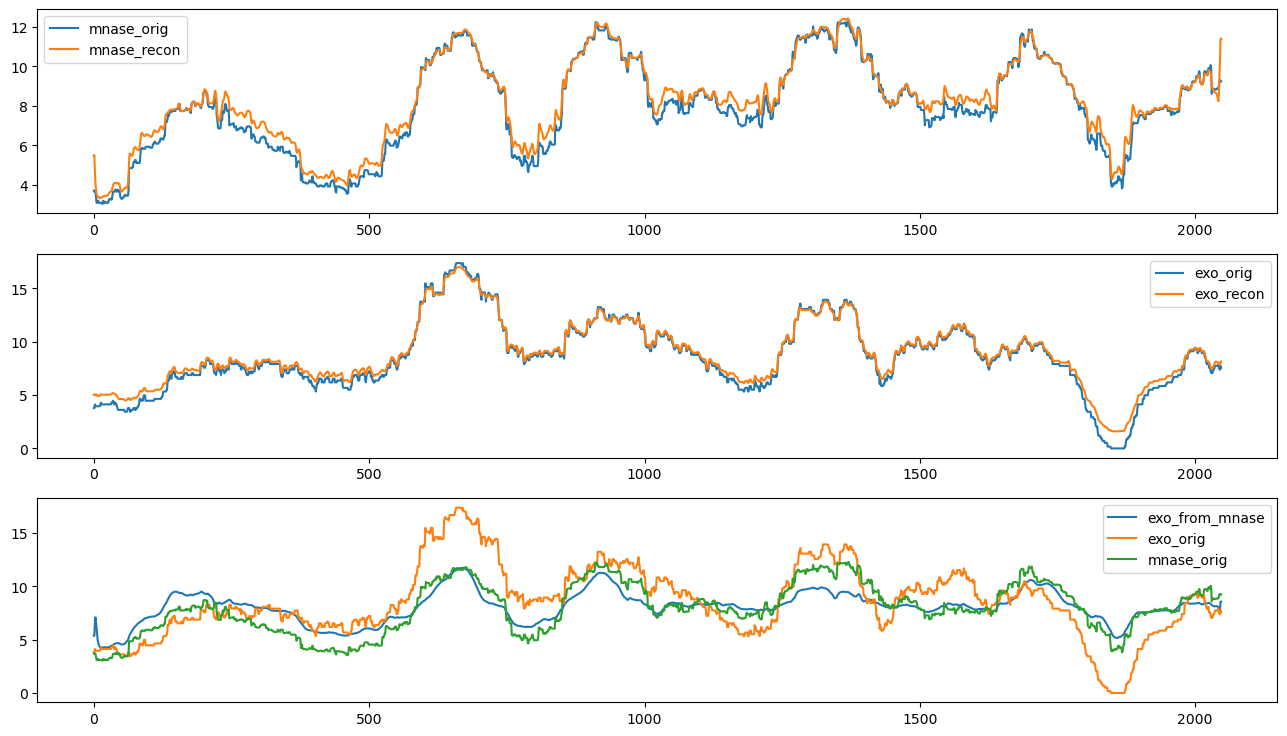

In [50]:
idx = 41
mnase_fignal = mnase_orig[idx]
exo_signal = exo_orig[idx]
mnase_recon_idx = manse_recon[idx]
exo_recon_idx = exoIII_recon[idx]
manse_to_exoIII_recon_idx = manse_to_exoIII_recon[idx]

fig, axs = plt.subplots(3, 1, figsize=(16, 9))


axs[0].plot(mnase_fignal, label="mnase_orig")
axs[0].plot(mnase_recon_idx, label="mnase_recon")


axs[1].plot(exo_signal, label="exo_orig")
axs[1].plot(exo_recon_idx, label="exo_recon")


axs[2].plot(manse_to_exoIII_recon_idx, label="exo_from_mnase")
axs[2].plot(exo_signal, label="exo_orig")
axs[2].plot(mnase_fignal, label="mnase_orig")

axs[0].legend()
axs[1].legend()
axs[2].legend()